In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
pd.set_option("display.max_columns", None)      # view ALL columns in DataFrames
# pd.reset_option("display.max_columns")        # reset to default
from drawarrow import ax_arrow
from highlight_text import fig_text, ax_text
from scipy.stats import gaussian_kde
# personalisation
plt.rcParams.update({
    "font.family": "Georgia",
    "font.size": 11,
    "lines.linewidth": 1,
})

# Import Data

In [ ]:
df = pd.read_parquet("../data/strava_activities.parquet")

keep = [
    "activity_id", "name", "type",
    "start_datetime", "end_datetime",
    "date", "month", "weekday", "start_hour",
    "distance_km", "distance_miles",
    "moving_time_mins", "elapsed_time_mins",
    "avg_pace_km", "avg_pace_mile",
    "avg_hr", "max_hr", "avg_cadence_spm",
    "total_elev_gain",
    "shoe", "num_comments", "num_achievements", "num_kudos"
]

df = df[keep]

# Kernel Density Estimation (KDE) Plot

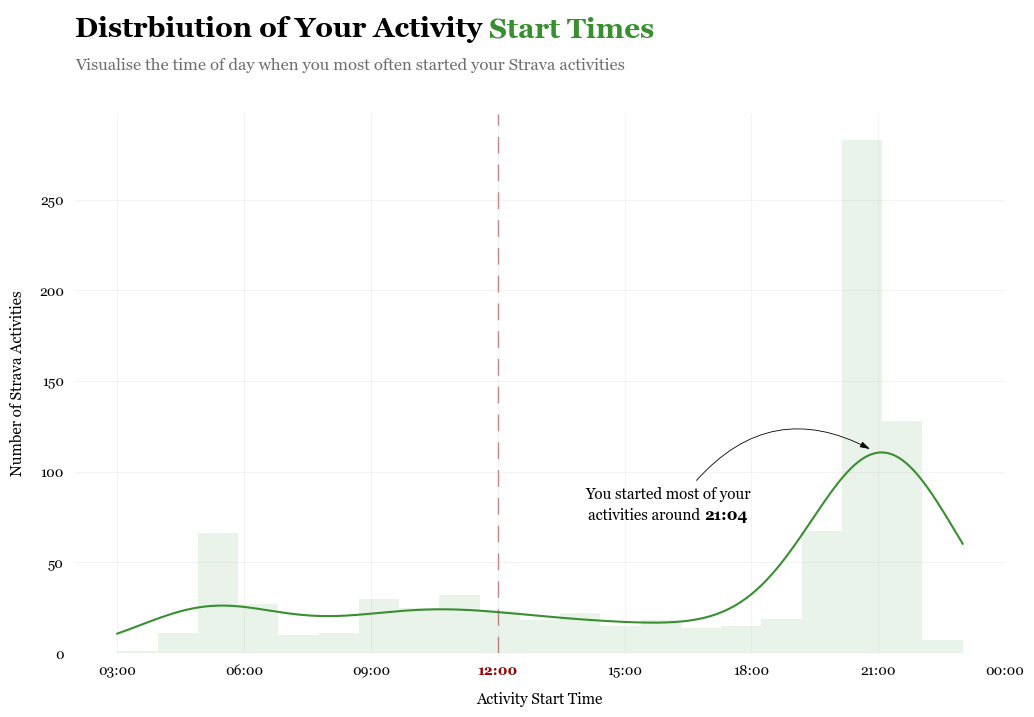

In [ ]:
# choose colours
midday_colour = "#950404FF"
line_colour = "#388F30FF"

# create a figure for visualisation
fig, ax = plt.subplots(figsize=(12, 7))

# axes customisation
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)    # remove all plot borders
ax.grid(True, alpha=0.15)                                           # add a light background grid   
ax.tick_params(length=0, pad=8, labelsize=10)

# axis ticks spacing
x_range = np.arange(0, 25, 3)
ax.set_xticks(x_range)

# hardcode the 24:00 label as 00:00
xtick_labels = [f"{int(x_range[i]):02d}:00" for i in range(len(x_range) - 1)] + [f"00:00"]
ax.set_xticklabels(xtick_labels)

ax.set_xlabel("Activity Start Time", labelpad=10)
ax.set_ylabel("Number of Strava Activities", labelpad=10)

# plot histogram (COUNTS, not density)
counts, bins, _ = ax.hist(
    df["start_hour"].dropna(),
    bins=21,
    color=line_colour,
    edgecolor=None,
    linewidth=0.6,
    alpha=0.1,
)

# construct KDE with scipy function
data = df["start_hour"].dropna().to_numpy()
kde = gaussian_kde(data)

# get x and y values
x_kde = np.linspace(data.min(), data.max(), 500)
y_kde = kde(x_kde)

# scale KDE to match counts
bin_width = bins[1] - bins[0]
y_kde_scaled = y_kde * len(data) * bin_width

# plot scaled line plot
ax.plot(
    x_kde, y_kde_scaled,
    color=line_colour, 
    linewidth=1.5
)

# find the peak point
peak_idx = np.argmax(y_kde_scaled)
x_peak, y_peak = x_kde[peak_idx], y_kde_scaled[peak_idx]

# shaded band around noon
# ax.axvspan(11.85, 12.15, color=midday_colour, alpha=0.08)
ax.axvline(
    x=12,
    linestyle=(0, (12, 8)),
    color=midday_colour,
    alpha=0.5,
    zorder=1
)

# colour only the midday (12:00) tick label
for label, tick in zip(ax.get_xticklabels(), x_range):
    if tick == 12:
        label.set_color(midday_colour)
        label.set_fontweight("bold")   

# arrow: point to the peak
x_tail, y_tail = x_peak * .76, y_peak * .85
ax_arrow(
    head_position=(x_peak * .99, y_peak * 1.01),
    tail_position=(x_tail * 1.04, y_tail),
    fill_head=True,
    head_width=1.8,
    head_length=6,
    color="black",
    radius=-0.4,
    width=0.6
)

# annotation text: state peak activity 
hours = int(x_peak)
minutes = int((x_peak - hours) * 60)
ax_text(
    x=x_tail, y=y_tail * 0.87,
    s=f"You started most of your\nactivities around <{hours:02d}:{minutes:02d}>",    
    highlight_textprops=[
        {"weight": "bold"},
    ], 
    textalign="center",
    ha="center",
    va="center",
    fontsize=11,
    linespacing=1.45
)

# chart title
x_value, y_value = 0.125, 1.02
fig_text( 
    x=x_value, y=y_value, 
    s=f"Distrbiution of Your Activity <Start Times>", 
    highlight_textprops=[
        {"color": line_colour, "weight": "bold"},
    ], 
    fontsize=20,
    weight="bold"
)

# chart subtitle
fig.text(
    x=x_value,
    y=y_value * 0.925,
    s="Visualise the time of day when you most often started your Strava activities",
    size=12,
    color="#6e6e6e"
)

# save figure as SVG
plt.savefig("../images/activity_start_time_kde.svg", bbox_inches="tight")

plt.show()